In [31]:
import mujoco
import numpy as np
from mujoco import viewer
# from mujoco import mjx
import time
import cvxpy as cp
from scipy import linalg
import matplotlib.pyplot as plt
import pandas as pd

In [32]:
# MJCF XML as string
mjcf = """
<mujoco model="4link_tendon_planar">
    <compiler angle="radian"/>
    <option gravity="0 0 -9.81" integrator="implicitfast"/>

    <default>
        <joint type="hinge" axis="0 1 0" limited="true" range="-1.57 1.57" damping="0.01"/>
        <geom type="capsule" size="0.005 0.03" rgba="0.5 0.5 0.5 1" mass="0.01"/>
    </default>


    <worldbody>
        <camera name="side_view" pos="0 0.1 0.05" xyaxes="1 0 0  0 0 1"/>
        <body name="link1" pos="0 0 0">
            <joint name="joint1" />
            <geom fromto="0 0 0 0.06 0 0" size="0.005"/>
            <body name="link2" pos="0.06 0 0">
                <joint name="joint2"/>
                <geom fromto="0 0 0 0.06 0 0" size="0.005"/>
                <body name="link3" pos="0.06 0 0">
                    <joint name="joint3"/>
                    <geom fromto="0 0 0 0.06 0 0" size="0.005"/>
                    <body name="link4" pos="0.06 0 0">
                        <joint name="joint4"/>
                        <geom fromto="0 0 0 0.06 0 0" size="0.005"/>
                        <body name="attachment" pos="0.03 0.0 0.0">
                              <site name="ee" rgba="1 0 0 1" size="0.001" group="1"/>
                        </body>
                    </body>
                </body>
            </body>
        </body>
    </worldbody>

    <!-- Tendon-based antagonistic actuation -->
    <tendon>
        <!-- Tendon pair A -->
        <fixed name="tendon_a_flex">
            <joint joint="joint1" coef="1"/>
            <joint joint="joint2" coef="1"/>
        </fixed>
        <fixed name="tendon_a_ext">
            <joint joint="joint1" coef="-1"/>
            <joint joint="joint2" coef="-1"/>
        </fixed>

        <!-- Tendon pair B -->
        <fixed name="tendon_b_flex">
            <joint joint="joint3" coef="1"/>
            <joint joint="joint4" coef="1"/>
        </fixed>
        <fixed name="tendon_b_ext">
            <joint joint="joint3" coef="-1"/>
            <joint joint="joint4" coef="-1"/>
        </fixed>
    </tendon>


    <!-- Actuators for tendons -->
    <actuator>
        <motor tendon="tendon_a_flex" ctrlrange="0 1" gear="0.1"/>
        <motor tendon="tendon_a_ext" ctrlrange="0 1" gear="0.1"/>
        <motor tendon="tendon_b_flex" ctrlrange="0 1" gear="0.1"/>
        <motor tendon="tendon_b_ext" ctrlrange="0 1" gear="0.1"/>
    </actuator>
</mujoco>

"""  # Replace with the MJCF content provided above


In [33]:
# Load model from string
model = mujoco.MjModel.from_xml_string(mjcf)
data = mujoco.MjData(model)
model.jnt_stiffness[:] = 0.01

damping_ratio = 1.0

In [34]:
def get_coriolis_and_gravity(model, data):
    """
    Calculate the Coriolis matrix and gravity vector for a MuJoCo model

    Parameters:
        model: MuJoCo model object
        data: MuJoCo data object

    Returns:
        C: Coriolis matrix (nv x nv)
        g: Gravity vector (nv,)
    """
    nv = model.nv  # number of degrees of freedom

    # Calculate gravity vector
    g = np.zeros(nv)
    dummy = np.zeros(nv,)
    mujoco.mj_factorM(model, data)  # Compute sparse M factorization
    mujoco.mj_rne(model, data, 0, dummy)  # Run RNE with zero acceleration and velocity
    g = data.qfrc_bias.copy()

    # Calculate Coriolis matrix
    C = np.zeros((nv, nv))
    q_vel = data.qvel.copy()

    # Compute each column of C using finite differences
    eps = 1e-6
    for i in range(nv):
        # Save current state
        vel_orig = q_vel.copy()

        # Perturb velocity
        q_vel[i] += eps
        data.qvel = q_vel

        # Calculate forces with perturbed velocity
        mujoco.mj_rne(model, data, 0, dummy)
        tau_plus = data.qfrc_bias.copy()

        # Restore original velocity
        q_vel = vel_orig
        data.qvel = q_vel

        # Compute column of C using finite difference
        C[:, i] = (tau_plus - data.qfrc_bias) / eps

    return C, g

In [35]:
def compute_jacobian_derivative(model, data, site_id, h=1e-6):
    """
    Compute the time derivative of the Jacobian in MuJoCo.
    
    Parameters:
    - model: The MuJoCo model (mjModel).
    - data: The MuJoCo data structure (mjData).
    - jac_func: Function to compute the Jacobian (e.g., mj_jacBody or mj_jacSite).
    - h: Small positive step for numerical differentiation.
    
    Returns:
    - Jdot: The time derivative of the Jacobian.
    """
    # Step 1: Update kinematics
    mujoco.mj_kinematics(model, data)
    mujoco.mj_comPos(model, data)
    
    # Step 2: Compute the initial Jacobian
    J = np.zeros((6, model.nv))  # Assuming a 6xnv Jacobian for full spatial representation
    mujoco.mj_jacSite(model, data, J[:3], J[3:], site_id)
    
    # Step 3: Integrate position using velocity
    qpos_backup = np.copy(data.qpos)  # Backup original qpos
    mujoco.mj_integratePos(model, data.qpos, data.qvel, h)
    
    # Step 4: Update kinematics again
    mujoco.mj_kinematics(model, data)
    mujoco.mj_comPos(model, data)
    
    # Step 5: Compute the new Jacobian
    Jh = np.zeros((6, model.nv))
    mujoco.mj_jacSite(model, data, Jh[:3], Jh[3:], site_id)
    
    # Step 6: Compute Jdot
    Jdot = (Jh - J) / h
    
    # Step 7: Restore qpos
    data.qpos[:] = qpos_backup
    
    return Jdot


In [36]:
def controller(model, data):

    # Initialize 6×nv Jacobian matrix: top 3 rows for linear velocity, bottom 3 for angular velocity.
    # This will store the spatial Jacobian of the end-effector site, mapping joint velocities to task-space twist.
    jac = np.zeros((6, model.nv))
    
    #used to store the position error of the end-effector in 3D space
    twist = np.zeros(3)

    # This will later store the inverse of the mass matrix for the robot, which maps forces to accelerations
    M_inv = np.zeros((model.nv, model.nv))

    # Mass matrix
    M = np.zeros((model.nv, model.nv))
    
    # Joint-space proportional gain vector for a nullspace PD controller
    # np.asarray(a) creates a NumPy array only if not already one
    Kp_null = np.asarray([1] * model.nv)

    # This computes the derivative gain (D-gain) for a critically damped PD controller
    Kd_null = damping_ratio * 2 * np.sqrt(Kp_null)

    # Dimension of task space (Cartesian end-effector space)
    m = 3

    # F is R 6x6 because eta = [y,y_dot]^T
    F = np.zeros((2*m,2*m))

    # Set the top-right block of F to identity
    F[:m,m:] = np.eye(m,m)
    
    # Same thing for G
    G = np.zeros((2*m,m))
    G[m:,:] = np.eye(m)
    
    # epsilon
    e = 0.03
    
    # linalg.block_diag combines two matrices into a block diagonal matrix
    # linalg.solve_continuous_are is a SciPy function that solves the continuous-time algebraic Riccati equation
    # Scaled P with e so that position error has a much bigger contribution to V, prioritizing position error over velocity error
    # Use Riccati equation to solve for P instead of Lyapunov equation to bias our optimizer to find solutions near the locally optimal LQR gain
    Pe = linalg.block_diag(np.eye(m) / e, np.eye(m) ).T @ linalg.solve_continuous_are(F, G, np.eye(2*m), np.eye(m)) @ linalg.block_diag(np.eye(m) / e, np.eye(m) )
    
    # pseudo B maps inputs to joint torques
    pinv_B = np.linalg.pinv(B)
    
    # Name of the MuJoCo site representing the end-effector (y)
    site_name = "ee"
    
    # Get the numeric ID of the MuJoCo site named "ee"
    site_id = model.site(site_name).id

    # Position error in 3D
    dx = np.array([0.1, 0.0, -0.15]) - data.site(site_id).xpos
    twist = dx 

    # Get the current joint positions q (generalized coordinates)
    q = data.qpos
    # print(q)
    
    # Updates all body and site positions/orientations (like end-effector pose)
    # Using the current joint configuration in data.qpos.
    mujoco.mj_kinematics(model,data)
    
    # Computes the center-of-mass POSITIONS for all bodies in the model.
    # Must be called before using any CoM-based quantities (like dynamics).
    mujoco.mj_comPos(model,data)

    # Computes the spatial Jacobian of the site (e.g., end-effector).
    # jac[:3] gets linear velocity Jacobian (∂x/∂q)
    # jac[3:] gets angular velocity Jacobian (∂ω/∂q)
    # This is necessary for task-space control or computing end-effector velocity.
    mujoco.mj_jacSite(model, data, jac[:3], jac[3:], site_id)
    
    # Compute the task-space inertia matrix and stores it in M_inv.
    mujoco.mj_solveM(model, data, M_inv, np.eye(model.nv))
    
    # This fills in the full (dense) joint-space mass matrix M(q) into the array M.
    mujoco.mj_fullM(model, M, data.qM)
    
    # Numerically computes the time derivative of the full spatial Jacobian of the site
    dJ_dt_full = compute_jacobian_derivative(model, data, site_id)
    
    # Extracts just the linear velocity part (top 3 rows) of the full Jacobian time derivative
    dJ_dt = dJ_dt_full[:3,:]
    jac = jac[:3,:]
    
    # 4 control inputs
    nu = 4

    # Retrieve number of joint position variables
    nq = model.nq

    # cp.Variable() is a function from the CVXPY library, which is a Python tool for convex optimization. It creates a symbolic variable that you can include in cost functions and constraints.
    
    # Decision variable for the two actuator inputs
    u = cp.Variable(shape=(2, 1))

    # Decision variable for mu (task)
    mu = cp.Variable(shape=(dx.shape[0], 1))

    # A slack variable for relaxing the Lyapunov stability constraint
    dl = cp.Variable(shape=(1, 1))
    

    # [y,y_dot]
    eta = np.concatenate((-twist,jac @ data.qvel))

    # Lyapunov function
    V = eta.T @ Pe @ eta
    

    # The function get_coriolis_and_gravity() returns two values, but the Coriolis matrix C is not needed, so you use _ to ignore it
    _, g = get_coriolis_and_gravity(model, data)

    # data.qfrc_spring is a MuJoCo internal variable containing joint torques from spring-like forces, if any joint stiffness or compliance is defined
    # This computes the total static generalized torques acting on the joints without any movement?? 
    statics = (g + data.qfrc_spring)

    # data.qvel is a 1D NumPy array of shape (nq,), representing generalized joint velocities in MujoCo
    # reshape(-1, 1) converts the flat vector into a column vector of shape (nq, 1)
    # flat vector is simply a 1D array like [1 2 3]
    dq = data.qvel.reshape(-1,1)
    # print(dq)

    # Defines a joint-space acceleration command ddq for the nullspace controller
    # PD or impedance?? Impedance!
    ddq = Kp_null * (- data.qpos) - 4*Kd_null * data.qvel

    
    # Unclear??
    # null = 0.1*B @ pinv_B @ ddq.reshape(-1,1)
    # damp = cp.square(cp.norm(B @ u - null))
    
    # Maps 2 actuator control inputs into 4 joint torques
    Bp = np.array([[0.1, 0.0], [0.1, 0.0], [0.0, 0.1], [0.0, 0.1]])
    
    # Bp @ u computes the joint torques generated by the 2 tendon actuators using the tendon-to-joint mapping matrix Bp??
    qdd_cl = (Bp @ u - data.qfrc_bias.reshape(-1,1) - data.qfrc_passive.reshape(-1,1))
    
    # E_dot  
    Vw = (dq.T @ qdd_cl + (q*model.jnt_stiffness[:]).T @ dq)

    # E
    E = 1/2 * dq.T @ M @ dq
    
    # Compute V_dot
    dV = eta.T @ (F.T @ Pe + Pe @ F) @ eta + 2 * eta.T @ Pe @ G @ mu

    
    # Unclear??
    u_des = np.linalg.pinv(Bp)  @ (M @ np.linalg.pinv(jac) @ (100 * twist - 20 * (jac @ data.qvel) - dJ_dt @ data.qvel) + data.qfrc_bias + data.qfrc_passive) #+ 0.1 * pinv_B @ (np.eye(model.nv) - jac.T @ Jbar.T) @ ddq
    
    # Lie derivatives
    L2fy = dJ_dt @ dq - jac @ M_inv @ (data.qfrc_bias.reshape(-1,1) + data.qfrc_passive.reshape(-1,1))
    LgLfy = jac @ M_inv @ Bp

    # Cost Weights
    mu_weight = 0.00001
    dl_weight = 10000

    # # Cost Weights
    # tracking = 1
    # qdd_weight = 0.02
    # u_weight = 0.01
    # dl_weight = 1000

    # Cost function
    objective = cp.Minimize(cp.square(cp.norm(mu)) + dl_weight*cp.square(cp.norm(dl))) # objective
    
    # regularization term (reducing can help decrease error)!!!

    # Constraints
    constraints = [ 
                    dV <= -2/e * V + dl,
                #    Vw <= - 50*  E + 0.1*dl,
                    L2fy + LgLfy @ u == mu,
                    -1.0 <= u,
                    1.0 >= u
    ]
    # This line creates an optimization problem object named prob.
    prob = cp.Problem(objective=objective, constraints=constraints)
    
    # This line solves the optimization problem defined earlier using CVXPY
    # verbose=False tells the solver not to print output to the console while solving
    prob.solve(verbose=False)
   
    # Compute dV
    dV = dV.value

    # Compute optimized dl
    dl = float(dl.value)
   
    # Compute optimized control inputs
    u = np.array([np.max([u.value[0][0],0.0]), - np.min([u.value[0][0],0.0]), np.max([u.value[1][0],0.0]), - np.min([u.value[1][0],0.0])])

    task_error = np.linalg.norm(dx)


    # data.ctrl is assigning control inputs to MuJoCo, and np.squeeze(u) ensures the array is flat
    data.ctrl = np.squeeze(u)
        # data.ctrl = np.array([0.0]*4)
        # print(u.value)
        # print(qdd.value)
        # print(B @ u.value)
    # print(dx)
        # print("damping: ", np.linalg.norm(B @ u.value - null), "statics: ", np.linalg.norm(B @ u.value - statics.reshape(-1,1)))
    # except:
    #     print(u.value)
    #     print(f"failed convergence\n")
    #     pass
    return V, dV, dl, e, u, task_error, dq


In [37]:
def compute_B_matrix(model, data):
    nv, nu = model.nv, model.nu
    B = np.zeros((nv, nu))

    ctrl_backup = data.ctrl.copy()

    for i in range(nu):
        data.ctrl[:] = 0.0
        data.ctrl[i] = 1.0
        mujoco.mj_forward(model, data)
        B[:, i] = data.qfrc_actuator

    data.ctrl[:] = ctrl_backup  # Restore control inputs
    return B

In [38]:
# Print actuator matrix
B = compute_B_matrix(model, data)
print("Actuator matrix B (joint_accels = B @ actuator_forces):\n", B)

Actuator matrix B (joint_accels = B @ actuator_forces):
 [[ 0.1 -0.1  0.   0. ]
 [ 0.1 -0.1  0.   0. ]
 [ 0.   0.   0.1 -0.1]
 [ 0.   0.   0.1 -0.1]]


In [39]:
V_log = []
V_dot_log = []
bound_log = []
u_log = []
tau_log = []
task_error_log = []
delta = []
q_vel = []
q_pos = []
time_log = []
t = 0.0
dt = model.opt.timestep

# Simulate
try:
    with viewer.launch_passive(model, data) as v:
        v.cam.azimuth = 90
        v.cam.elevation = 5
        v.cam.distance =  1
        v.cam.lookat = np.array([0.0 , 0.0 , -0.1])
        # print("Press ESC to exit viewer.")
        while v.is_running() and t < 1.4:
            # You can set control inputs here, for example:
            # data.ctrl[:] = [0.5, 0.3, 0.1, 0.2]  # Example tendon control values
            V, dV, dl, e, u, task_error, dq = controller(model, data)  # <-- modify controller to return V
            B = compute_B_matrix(model, data)
            V_log.append(V)
            V_dot_log.append(dV)
            bound_log.append(-V/e + dl)
            u_log.append(u)
            tau_log.append(B @ u)
            task_error_log.append(task_error)
            delta.append(dl)
            # Joint Velocities
            q_vel.append(dq.squeeze().copy())
            time_log.append(t)
            t += dt
            mujoco.mj_step(model, data)
            v.sync()
            time.sleep(0.001)
except ImportError:
    print("Viewer requires glfw, and a GUI environment.")

C:\Users\12166\AppData\Local\Temp\ipykernel_36572\2891530874.py:193: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dl = float(dl.value)


In [40]:
# Create a DataFrame from the simulation logs
u_log = np.array(u_log)        # shape (T, 4)
tau_log = np.array(tau_log)    # shape (T, 4)
q_vel = np.array(q_vel)

df = pd.DataFrame({
    'time': time_log,
    'V': V_log,
    'V_dot': V_dot_log,
    'q_vel_0': q_vel[:, 0],
    'q_vel_1': q_vel[:, 1],
    'q_vel_2': q_vel[:, 2],
    'q_vel_3': q_vel[:, 3],
    'stability_bound': bound_log,
    'task_error': task_error_log,
    'u_0 (A Flexor)': u_log[:, 0],
    'u_1 (A Extensor)': u_log[:, 1],
    'u_2 (B Flexor)': u_log[:, 2],
    'u_3 (B Extensor)': u_log[:, 3],
    'tau_0': tau_log[:, 0],
    'tau_1': tau_log[:, 1],
    'tau_2': tau_log[:, 2],
    'tau_3': tau_log[:, 3]
})

# Save the DataFrame to a CSV file
df.to_csv(r"D:\Control\Soft Arm Project\controller_logs.csv", index=False)

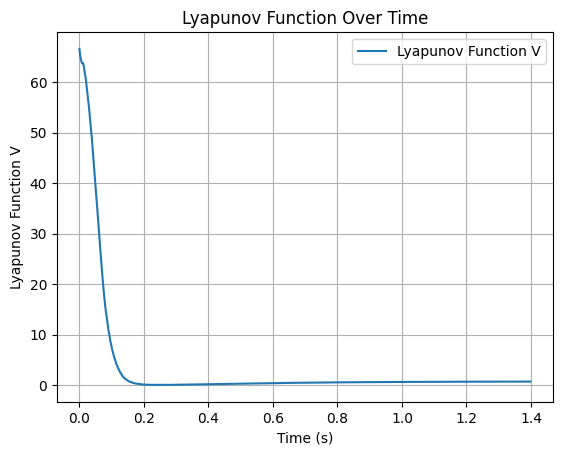

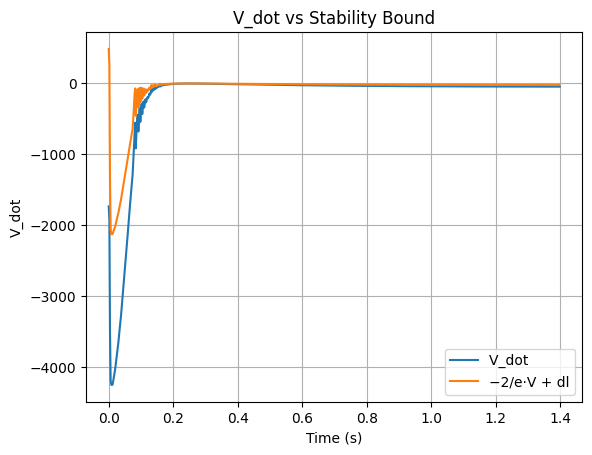

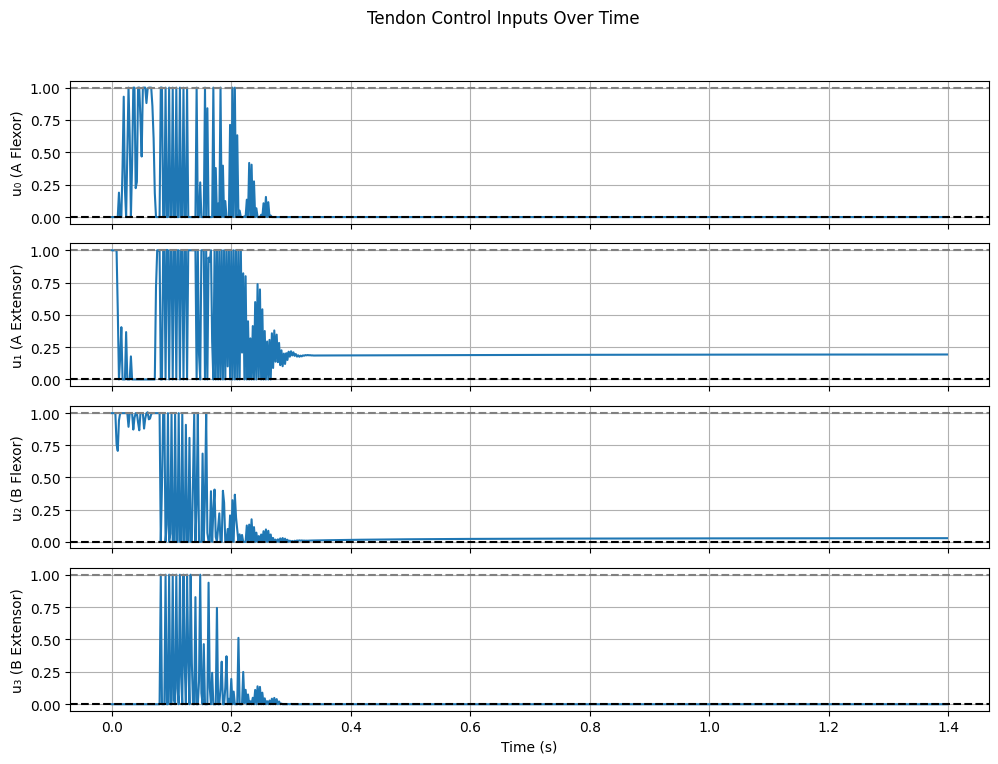

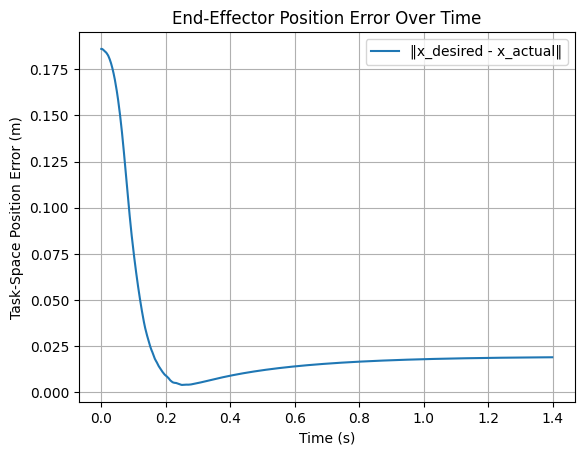

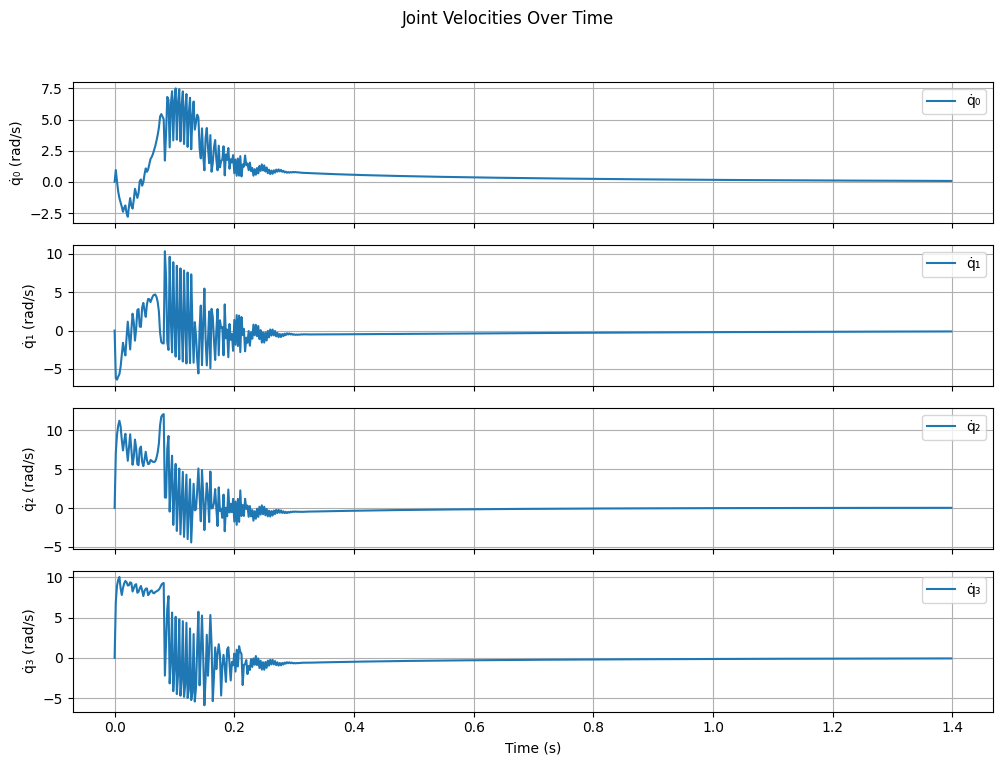

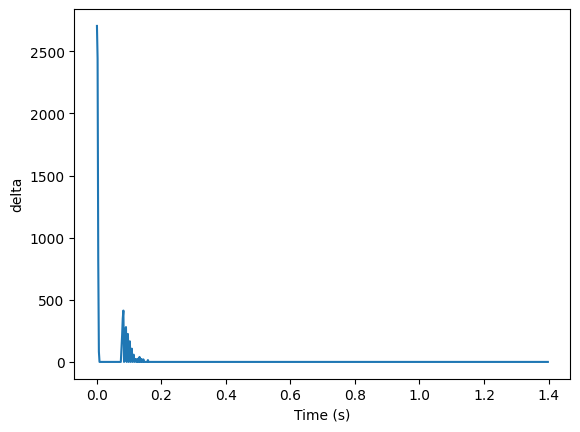

In [41]:
#Lyapunov Function Over Time – shows how stability evolves.
plt.figure()
plt.plot(time_log, V_log, label="Lyapunov Function V")
plt.xlabel("Time (s)")
plt.ylabel("Lyapunov Function V")
plt.title("Lyapunov Function Over Time")
plt.grid(True)
plt.legend()  # <--- Add legend


#Lyapunov Derivative vs Stability Bound – confirms dV ≤ -2/ε * V + δ is met.
plt.figure()
plt.plot(time_log, V_dot_log, label="V_dot ")
plt.plot(time_log, bound_log, label="−2/e·V + dl")
plt.xlabel("Time (s)")
plt.ylabel("V_dot")
plt.title("V_dot vs Stability Bound")
plt.grid(True)
plt.legend()  # <--- Add legend

#Control Inputs – tracks actuator commands across time.
u_log = np.array(u_log)  # Ensure it's a NumPy array
labels = [
    "u₀ (A Flexor)",
    "u₁ (A Extensor)",
    "u₂ (B Flexor)",
    "u₃ (B Extensor)"
]
# Create 4 stacked subplots
fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

for i in range(4):
    axs[i].plot(time_log, u_log[:, i], label=labels[i])
    axs[i].axhline(1.0, color='gray', linestyle='--')
    axs[i].axhline(0.0, color='black', linestyle='--')
    axs[i].set_ylabel(labels[i])
    axs[i].grid(True)

axs[-1].set_xlabel("Time (s)")
fig.suptitle("Tendon Control Inputs Over Time")
fig.tight_layout(rect=[0, 0.03, 1, 0.95])


#End-Effector Position Error – checks task-space convergence.
plt.figure()
plt.plot(time_log, task_error_log, label="‖x_desired - x_actual‖")
plt.xlabel("Time (s)")
plt.ylabel("Task-Space Position Error (m)")
plt.title("End-Effector Position Error Over Time")
plt.grid(True)
plt.legend()


# Joint Velocities (q̇) – shows how joints move dynamically with 4 stacked subplots
labels = ["q̇₀", "q̇₁", "q̇₂", "q̇₃"]

fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

for i in range(4):
    axs[i].plot(time_log, q_vel[:, i], label=labels[i])
    axs[i].set_ylabel(f"{labels[i]} (rad/s)")
    axs[i].legend()
    axs[i].grid(True)

axs[-1].set_xlabel("Time (s)")
fig.suptitle("Joint Velocities Over Time")
fig.tight_layout(rect=[0, 0.03, 1, 0.95])


plt.figure()
plt.plot(time_log,delta)
plt.xlabel("Time (s)")
plt.ylabel("delta")

#Joint Angles (q) – visualizes motion of each joint.


plt.show()

In [42]:
# Print final values
print("Final V is: ", V_log[-1])
print("Final error is: ", task_error_log[-1])


Final V is:  0.6973600630060927
Final error is:  0.01901594807174374
